# 01 · A browser is a scientific workspace

**Time:** 25 minutes · **Audience:** undergraduate / introductory graduate GIS and Earth science.

**By the end:** Read a real array, identify its axes, and distinguish data from a visual encoding.

[Run in JupyterLite](https://jltobias.github.io/JupyterLite-zarr-sql-views/lite/lab/index.html?path=01_start_here.ipynb) · [Earth lab](https://jltobias.github.io/JupyterLite-zarr-sql-views/lab/) · [Sources and licenses](https://jltobias.github.io/JupyterLite-zarr-sql-views/book/credits.html)

Run cells from top to bottom with **Shift+Enter**. The first kernel start downloads Python WebAssembly packages.
The bundled exercises need no data-service account. Save a copy with **File → Save and Export Notebook As** before clearing browser storage.

![Four-stage workflow: STAC discovery, Zarr reading, SQL selection, linked views](assets/pipeline.svg)

In [1]:
from course import *
import numpy as np
import matplotlib.pyplot as plt
print('Ready: Python + NumPy + local teaching data')

Ready: Python + NumPy + local teaching data


## 1. Predict before running

What could an array with shape `(3, 48, 48)` represent? Sketch three maps stacked on top of one another.
The source application treats a time-varying geographic field as a cube and links it to SQL selections.
Here, the browser lab uses **Zarrita + DuckDB-WASM + deck.gl**. Python notebooks use **NumPy + SQLite + Matplotlib** for portable exercises.
Both read the same Zarr values. This is a teaching adaptation, not a Python distribution of upstream.

In [2]:
meta, water = load_cube('ngami')
print(meta['title'])
print('Axes = time, latitude, longitude; shape =', water.shape)
print('Times:', meta['times'])
print('Units:', meta['units'])

Lake Ngami · observed surface water
Axes = time, latitude, longitude; shape = (3, 48, 48)
Times: ['2018', '2020', '2022']
Units: water detection frequency (0–1)


## 2. Look at one slice

Each number is the fraction of clear satellite observations classified as water during a year.
A value of 0.8 does **not** mean 80% of the pixel is water, nor water on 80% of calendar days.
White gaps are missing values after quality masking, not dry land.

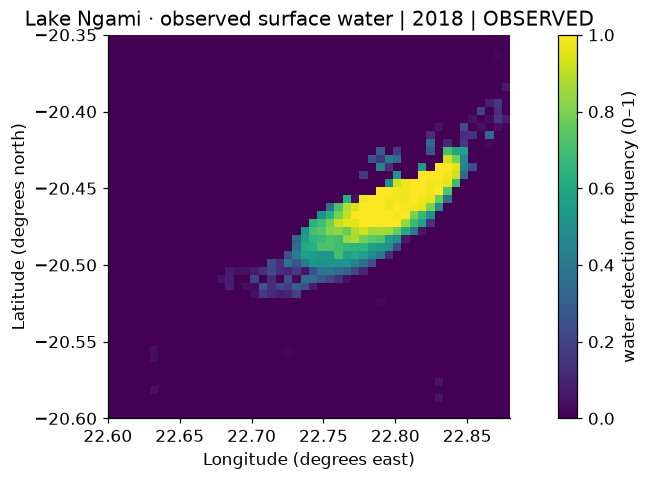

In [3]:
map_slice(meta, water, t=0);
plt.show()

## 3. Ask one small question

How many sampled cells had water detected in more than half of their clear observations?
Keep the denominator visible.

In [4]:
valid = np.isfinite(water[0])
selected = valid & (water[0] > 0.5)
print(f'{selected.sum()} selected / {valid.sum()} valid sampled cells')
assert np.all((water[valid[None].repeat(3, axis=0)] >= 0) | np.isnan(water[valid[None].repeat(3, axis=0)]))

127 selected / 2304 valid sampled cells


## 4. Move the same question into the lab

Choose **Lake Ngami**, type `value > 0.5 AND t = 0`, and run the query. Compare the count with Python.
Switch between 2D and 3D. Extrusion adds a visual height; it does not turn water frequency into terrain elevation.
The iframe needs the deployed course site. Use the link above it if embedding is restricted.

In [5]:
lab('ngami', 'map')

## Try it yourself

Change the year and threshold. Which changes the count more? Record both denominators.

## Check your reasoning

A threshold count describes sampled pixels and observation conditions. It cannot establish water volume, access, or a climate trend from three dates.

## Evidence journal

Write four sentences: **what I observed; how I calculated it; what this cannot establish; what evidence I need next**.
For any figure you reuse, retain its units, date or scenario, data origin, transformations, and attribution.

## Sources and credit

- [zarr-sql-views, source architecture and ISC license](https://github.com/dzole0311/zarr-sql-views)
- [Digital Earth Africa WOfS specifications and limitations](https://docs.digitalearthafrica.org/en/latest/data_specs/Landsat_WOfS_specs.html), CC BY 4.0 data.

Teaching adaptation of [dzole0311/zarr-sql-views](https://github.com/dzole0311/zarr-sql-views), ISC.
Original teaching code and prose: JupyterLite-zarr-sql-views contributors, ISC. Data keep their separate licenses.